In [74]:
# =============================================================================
# PROJECT SUMMARY
# =============================================================================

# OBJECTIVE:
# Build a machine learning model to predict the likelihood of loan default
# using real borrower and loan data.

# DATA:
# 32,581 loan applications from Kaggle with 12 features including borrower age,
# income, employment length, loan amount, interest rate, loan grade, and credit history.

# PROCESS:
# 1. Loaded and explored the dataset (EDA) — shape, summary stats, missing values, data types
# 2. Handled missing values in person_emp_length (895) and loan_int_rate (3,116) using median imputation
# 3. Encoded categorical variables using pd.get_dummies — expanded from 12 to 27 columns
# 4. Split data 80/20 into training and testing sets
# 5. Scaled features using StandardScaler to normalize columns on different scales
# 6. Trained a Logistic Regression model using the saga solver

# KEY FINDING:
# Initial model hit 86% accuracy but only 54% recall on actual defaulters.
# This is a class imbalance problem — far more non-defaulters than defaulters in the data.
# Applied class_weight='balanced' to penalize missed defaults more heavily.

# FINAL RESULT:
# Accuracy: 81% | AUC-ROC: 0.87 | Defaulter Recall: 78%
# The model correctly identifies 78 out of every 100 actual defaulters.

In [63]:
import pandas as pd
import yfinance as yf
import datetime as dt
import numpy as np
import matplotlib.pyplot as plt

In [64]:
# Green items are notes to self, to walk through my procress and thought process. Red items are code that I have deleted, but may want to reference later.

# Created a variable to hold the data
file_path = "/Users/tyrusburton/Desktop/Python-finance/credit_risk_dataset.csv"

# Used to read the csv file and store it in a variable called credit_data
credit_data = pd.read_csv(file_path)

# Shows the first 5 rows of the data, the info about the data, the description of the data, and the data types of each column.
print(credit_data.head(5))
print(credit_data.info())
print(credit_data.describe())
print(credit_data.dtypes)


   person_age  person_income person_home_ownership  person_emp_length  \
0          22          59000                  RENT              123.0   
1          21           9600                   OWN                5.0   
2          25           9600              MORTGAGE                1.0   
3          23          65500                  RENT                4.0   
4          24          54400                  RENT                8.0   

  loan_intent loan_grade  loan_amnt  loan_int_rate  loan_status  \
0    PERSONAL          D      35000          16.02            1   
1   EDUCATION          B       1000          11.14            0   
2     MEDICAL          C       5500          12.87            1   
3     MEDICAL          C      35000          15.23            1   
4     MEDICAL          C      35000          14.27            1   

   loan_percent_income cb_person_default_on_file  cb_person_cred_hist_length  
0                 0.59                         Y                           3  


In [65]:
# Above is the data that was pulled from Kaggle, it looks organized. The columns will be my variables, and the rows will be my observations. 
# I will be using this data to analyze credit risk, which is the risk of default on a loan. I will be using the columns to analyze the different factors 
# that contribute to credit risk, such as age, income, and credit score. I will also be using the target variable, which is the "loan_status" column, to analyze 
# the relationship between the different factors and the likelihood of default. 1 means the borrower defaulted, 0 means they did not.

In [66]:
# This line will be used to check for any missing values in the data, which is important to know before doing my analysis. If there are missing values, I'll need 
# to  decide how to handle them, either I fill them in with a value or drop the rows with missing values. 

print(credit_data.isnull().sum())

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64


In [67]:
# In this case, there are many missing values. The person_emp_length has 895 missing values, which is a lot. The person_emp_length column is the length of time the 
# borrower has been employed, which is an important factor in credit risk analysis.

# Also the loan_int_rate column is missing 3116 values, which is aslo a lot. The loan_int_rate column is the interest rate on the loan, which is an extremely important 
# factor in credit risk analysis.

# I have two options either drop the rows with missing values, or fill in the missing values with a median. In this case, I choose to fill with a median because 
# it is a more conservative approach and it won't distort the data as much as dropping rows would. (I used claude to help me with this decision, and it said that 
# filling with a median is a good approach because it is less likely to introduce bias into the model than filling with a mean, which can be skewed by outliers.)

# Filling with median introduces minor inaccuracy but is preferable to dropping rows or leaving nulls which would break the model

# 895 missing out of 32,581 rows for emp_length is only about 2.7% of the data small enough that filling it won't meaningfully distort the model
# 3,116 for interest rate is about 9.5% larger, but still workable. The median is a conservative, estimate because it represents the most typical value in the dataset

In [68]:
# Fill missing values with the median of each column
# credit_data['person_emp_length'] is how I select a single column from my dataFrame
# fillna = fill not available
# credit_data['person_emp_length'].median() calculates the median of the person_emp_length column, which is what I will use to fill in the missing values
credit_data['person_emp_length'] = credit_data['person_emp_length'].fillna(credit_data['person_emp_length'].median())
credit_data['loan_int_rate'] = credit_data['loan_int_rate'].fillna(credit_data['loan_int_rate'].median())

# This verifires no missing values remain
print(credit_data.isnull().sum())

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64


In [69]:
# No missing values left, so I can keep going.

# Next I need to handle the categorical columns the ones that contain text instead of numbers. The model can't read text. It only understands numbers. 
# So columns like person_home_ownership which says RENT, OWN, MORTGAGE and loan_intent which says MEDICAL, EDUCATION, PERSONAL all need to be converted to numbers.

# pd.get_dummies is a pandas function that converts text columns into numbers. "Dummies" refers to dummy variables 
# It takes each unique value in the column and creates a new column for each unique value, with a 1 if the row has that value and a 0 if it does not.
# The second credit_data overwrites the original credit_data which is important because I want to keep the changes I made to the daata.
credit_data = pd.get_dummies(credit_data, columns=['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file'])
print(credit_data.head())



   person_age  person_income  person_emp_length  loan_amnt  loan_int_rate  \
0          22          59000              123.0      35000          16.02   
1          21           9600                5.0       1000          11.14   
2          25           9600                1.0       5500          12.87   
3          23          65500                4.0      35000          15.23   
4          24          54400                8.0      35000          14.27   

   loan_status  loan_percent_income  cb_person_cred_hist_length  \
0            1                 0.59                           3   
1            0                 0.10                           2   
2            1                 0.57                           3   
3            1                 0.53                           2   
4            1                 0.55                           4   

   person_home_ownership_MORTGAGE  person_home_ownership_OTHER  ...  \
0                           False                        False 

In [70]:
 # Next steps I have to split the data. 

 # (Claude helped me with this explanation) 
 # The core idea why do we split the data? I'm building a model that predicts whether someone will default. If I train the model on ALL my data and then test it on 
 # that same data, it's like giving me the answer key before the exam. The model will look like it performs but it actually just memorized the data
 # it won't work on new loans it's never seen before.

 # So split the data into two separate groups: 
 # Training set — what the model learns from 
 # Testing set — new data the model has never seen, used to see how well it actually performs

In [71]:
# Imports the train_test_split function from the sklearn library, which is used to split the data into training and testing sets.
from sklearn.model_selection import train_test_split

# X = all the columns except loan_status(dropped by axis=1). These are the clues age, income, loan amount, etc.
# y = just the loan_status column. This is the answer did they default or not. 1 = default, 0 = no default. This is what the model is trying to predic
# So the model looks at X to make predictions, and you use y to check if it got it right.
X = credit_data.drop('loan_status', axis=1)
y = credit_data['loan_status']

# This splits both X and y at the same time into four pieces:
# X_train — 80% of the features for training
# X_test — 20% of the features for testing
# y_train — the corresponding answers for the training set
# y_test — the corresponding answers for the testing set
# means 20% goes to testing, 80% to training — the standard split.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Training set sixe:', X_train.shape)
print('Testing set size:', X_test.shape)

Training set sixe: (26064, 26)
Testing set size: (6517, 26)


In [72]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Scale data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Model build
model = LogisticRegression(max_iter=10000, solver='saga', class_weight='balanced')

# Model training
model.fit(X_train, y_train)

print("Model trained successfully.")

# Logistic regression looks at all the columns — age, income, loan grade, employment length etc — and figures out how much each one contributes to the likelihood 
# of someone defaulting. It then spits out a probability between 0 and 1 for each borrower. Like "this person has a 78% chance of defaulting" or "this person has 
# a 12% chance of defaulting." Then it makes a decision if the probability is above 50% it predicts default (1), below 50% it predicts no default (0).

# A logistic regression looks at all the information about a borrower and calculates the probability they will default. 
# (My understanding of this is that it assigns a weight to each factor, like age, income, loan amount, etc. Then it combines those weighted factors into a single 
# score that represents the likelihood of default. The higher the score, the more likely they are to default.)

# High probability = likely to default.
# Low probability = likely to pay it back.

# Why logistic regression for credit risk specifically: (Claude explanation for clarity)
# It's the foundation of how real credit scoring works. When a bank looks at a credit application they're essentially running a version of this 
# every factor about a applicant gets weighted and combined into a score that represents the default risk. Logistic regression maps directly to that logic. It's also 
# interpretable meaning you can look at the model and actually explain why it made a decision. That matters in finance because regulators require banks to be 
# able to explain why someone was denied credit. A black box model that just says "no" without explanation isn't acceptable.

Model trained successfully.


In [73]:
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

# Make predictions
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Detailed report
print(classification_report(y_test, y_pred))

# AUC-ROC Score
y_prob = model.predict_proba(X_test)[:,1]
print("AUC-ROC Score:", roc_auc_score(y_test, y_prob))

Accuracy: 0.8123369648611324
              precision    recall  f1-score   support

           0       0.93      0.82      0.87      5072
           1       0.55      0.78      0.65      1445

    accuracy                           0.81      6517
   macro avg       0.74      0.80      0.76      6517
weighted avg       0.85      0.81      0.82      6517

AUC-ROC Score: 0.8700900800104788


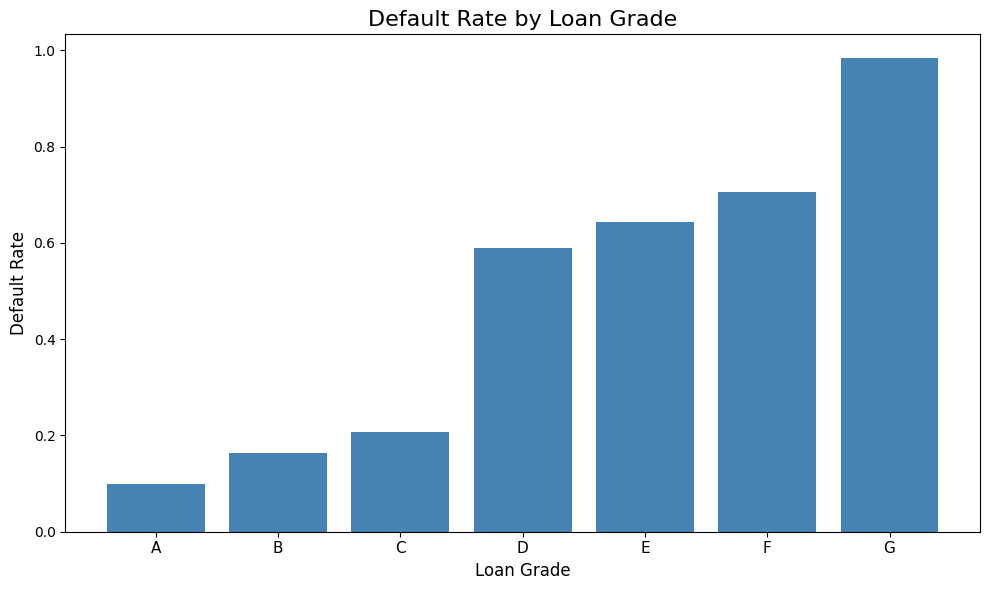

In [76]:
# Reload original data for visualizations before encoding
viz_data = pd.read_csv("/Users/tyrusburton/Desktop/Python-finance/credit_risk_dataset.csv")

# Default rate by loan grade
loan_grade_default = viz_data.groupby('loan_grade')['loan_status'].mean().sort_index()

plt.figure(figsize=(10, 6))
plt.bar(loan_grade_default.index, loan_grade_default.values, color='steelblue')
plt.title('Default Rate by Loan Grade', fontsize=16)
plt.xlabel('Loan Grade', fontsize=12)
plt.ylabel('Default Rate', fontsize=12)
plt.xticks(fontsize=11)
plt.tight_layout()
plt.show()

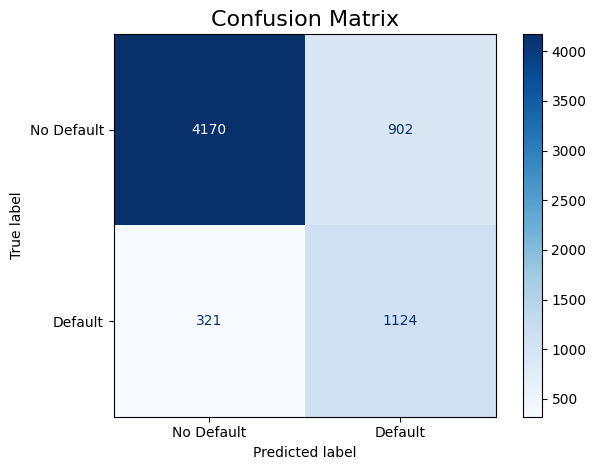

In [77]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Default', 'Default'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix', fontsize=16)
plt.tight_layout()
plt.show()

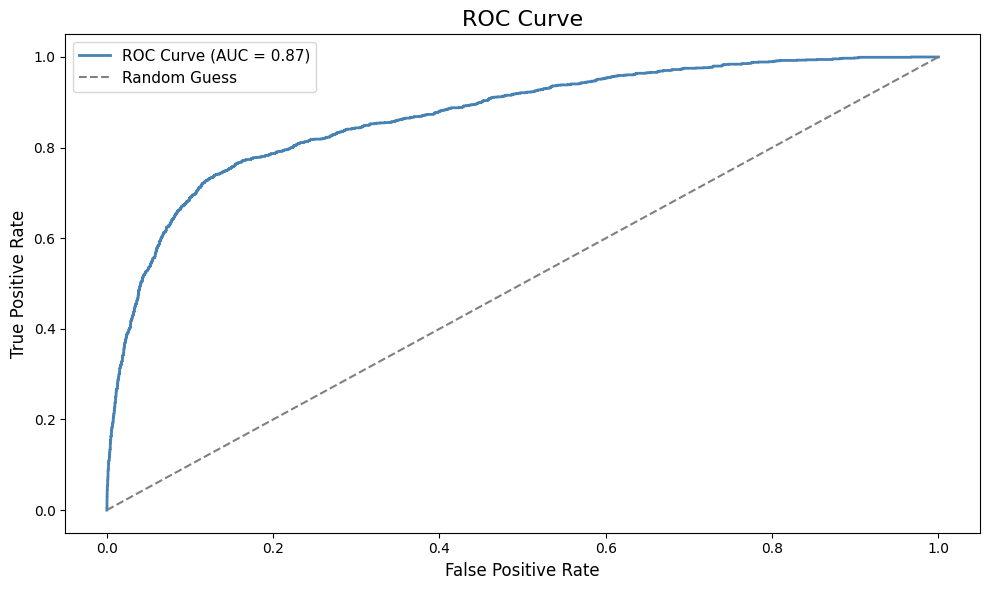

In [78]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='steelblue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Guess')
plt.title('ROC Curve', fontsize=16)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()